<a href="https://colab.research.google.com/github/Bhumiii27/ML-Labs/blob/main/ML_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [24]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("larsen0966/student-performance-data-set")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-performance-data-set' dataset.
Path to dataset files: /kaggle/input/student-performance-data-set


In [25]:
# Check downloaded files
import os

print(os.listdir(path))

['student-por.csv']


In [26]:
# Load dataset
data = pd.read_csv(path + "/student-por.csv")

data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [27]:
data.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [28]:
data = data[['studytime', 'absences', 'failures', 'G1', 'G2', 'G3']]
data.head()

,studytime,absences,failures,G1,G2,G3
0,2,4,0,0,11,11
1,2,2,0,9,11,11
2,2,6,0,12,13,12
3,3,0,0,14,14,14
4,2,0,0,11,13,13


In [29]:
X = data[['studytime', 'absences', 'failures', 'G1', 'G2']] #Input
y = data['G3'] #Output based on i/p

In [30]:
print("X:")
print(X.head())

print("\nY:")
print(y.head())

X:
   studytime  absences  failures  G1  G2
0          2         4         0   0  11
1          2         2         0   9  11
2          2         6         0  12  13
3          3         0         0  14  14
4          2         0         0  11  13

Y:
0    11
1    11
2    12
3    14
4    13
Name: G3, dtype: int64


In [31]:
#Training and Testing Data

In [32]:
#Splitting data 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (519, 5)
X_test : (130, 5)
y_train: (519,)
y_test : (130,)


In [34]:
#Linear Regression

In [35]:
model = LinearRegression()

In [36]:
model.fit(X_train, y_train)

LinearRegression()

In [37]:
print("studytime:", model.coef_[0])
print("absences:", model.coef_[1])
print("failures:", model.coef_[2])
print("G1:", model.coef_[3])
print("G2:", model.coef_[4])

studytime: 0.11416529186571879
absences: 0.02519170724774178
failures: -0.15393597808334464
G1: 0.18119976523233344
G2: 0.872573199470382


In [38]:
#Predict Test Score

In [39]:
y_pred = model.predict(X_test)

In [40]:
print(y_pred[:10])

[18.59755477 11.35196036 18.6779877  11.24633572 11.71435989 16.83575731
 17.62421474  9.16533992 10.49972106 10.52977058]


In [41]:
print(y_test.head(10).values)

[19 12 18 11 11 17 18  8 10 11]


In [42]:
#Evaluate
#MAE=Mean Absolute Error
#RMSE=Root Mean Squared Error
#R²=R-squared

In [43]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.7462407529568904
RMSE: 1.1547358286634248
R²: 0.8632635694850659


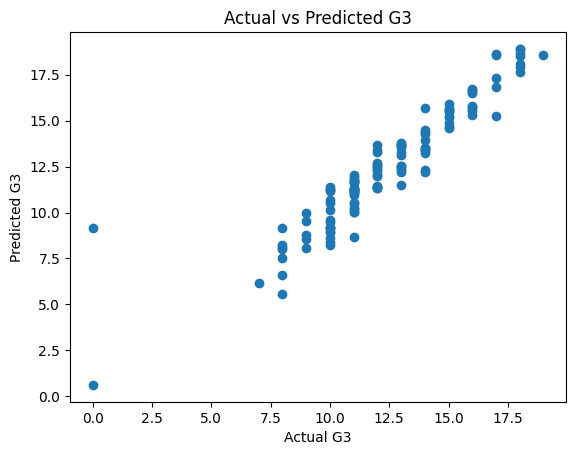

In [44]:
#Plot data actual vs predicted
plt.scatter(y_test, y_pred)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted G3")

plt.show()